# Lesson 13.1 - AI Safety & Alignment Fundamentals (scenario lab)

This notebook translates alignment concepts into operational design choices. You will model objective mismatch, inspect failure modes, and propose safer redesigns.
        


## Objectives

- Distinguish intended goals from proxy metrics.
- Analyze scenario-based alignment failures.
- Build a lightweight safety redesign checklist you can apply in product planning.
        


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)
        


## Scenario Set: Where Alignment Breaks

We use three realistic scenarios:

1. Engagement ranking (proxy CTR vs user well-being).
2. Ticket auto-prioritization (speed metric vs severity coverage).
3. Content moderation assistant (high recall target vs fairness and appeal quality).

For each scenario, separate:

- Intended objective.
- Operationalized metric.
- Likely loopholes.
- Safer design pattern.
        


In [2]:
scenarios = pd.DataFrame(
    [
        {
            "scenario": "Feed ranking",
            "intended_goal": "Long-term user value",
            "proxy_metric": "Click-through rate",
            "failure_mode": "Sensational content over-ranked",
            "safer_redesign": "Multi-objective ranking with quality constraints",
        },
        {
            "scenario": "Support triage",
            "intended_goal": "Resolve highest-risk tickets first",
            "proxy_metric": "Average handling time",
            "failure_mode": "Complex critical tickets deferred",
            "safer_redesign": "Risk-weighted SLA and escalation policy",
        },
        {
            "scenario": "Safety assistant",
            "intended_goal": "Prevent harmful responses",
            "proxy_metric": "Refusal rate",
            "failure_mode": "Over-refusal harms utility",
            "safer_redesign": "Context-aware policy and calibrated confidence",
        },
    ]
)

scenarios
        


,scenario,intended_goal,proxy_metric,failure_mode,safer_redesign
0,Feed ranking,Long-term user value,Click-through rate,Sensational content over-ranked,Multi-objective ranking with quality constraints
1,Support triage,Resolve highest-risk tickets first,Average handling time,Complex critical tickets deferred,Risk-weighted SLA and escalation policy
2,Safety assistant,Prevent harmful responses,Refusal rate,Over-refusal harms utility,Context-aware policy and calibrated confidence


## Toy Simulation: Proxy Optimization vs True Utility

We simulate a ranking system. The system optimizes predicted CTR, while the true objective is long-term satisfaction. This demonstrates outer alignment mismatch.
        


In [3]:
n_items = 500

quality = np.random.beta(4, 2, size=n_items)          # long-term value signal
clickbait = np.random.beta(2, 4, size=n_items)        # attention-grabbing signal
novelty = np.random.beta(2, 2, size=n_items)

# Proxy metric used by system
predicted_ctr = 0.65 * clickbait + 0.25 * novelty + 0.10 * quality

# True business objective
true_utility = 0.70 * quality + 0.20 * novelty - 0.25 * clickbait

items = pd.DataFrame(
    {
        "quality": quality,
        "clickbait": clickbait,
        "novelty": novelty,
        "predicted_ctr": predicted_ctr,
        "true_utility": true_utility,
    }
)

k = 50
proxy_top = items.sort_values("predicted_ctr", ascending=False).head(k)
true_top = items.sort_values("true_utility", ascending=False).head(k)

summary = pd.DataFrame(
    {
        "selection": ["Proxy-optimized top-k", "True-utility top-k"],
        "avg_predicted_ctr": [proxy_top["predicted_ctr"].mean(), true_top["predicted_ctr"].mean()],
        "avg_true_utility": [proxy_top["true_utility"].mean(), true_top["true_utility"].mean()],
        "avg_clickbait": [proxy_top["clickbait"].mean(), true_top["clickbait"].mean()],
    }
)
summary
        


,selection,avg_predicted_ctr,avg_true_utility,avg_clickbait
0,Proxy-optimized top-k,0.639802,0.444776,0.638328
1,True-utility top-k,0.405372,0.692181,0.241750


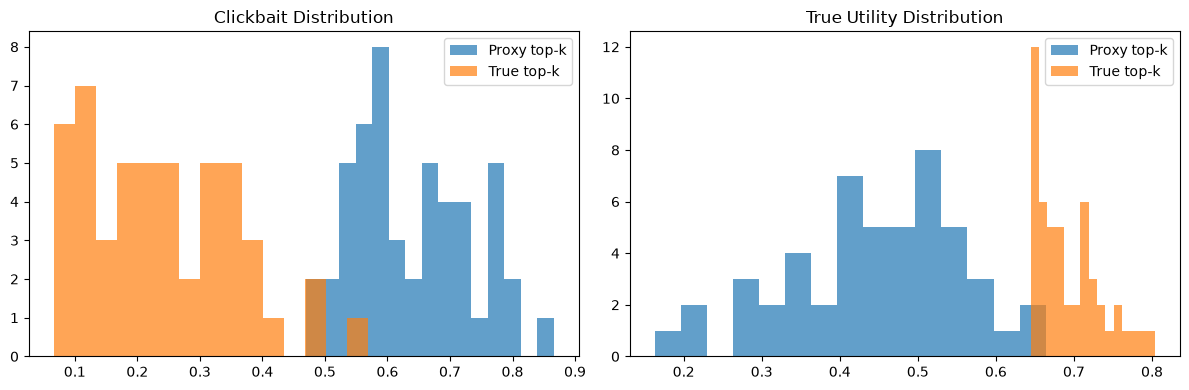

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(proxy_top["clickbait"], bins=15, alpha=0.7, label="Proxy top-k")
axes[0].hist(true_top["clickbait"], bins=15, alpha=0.7, label="True top-k")
axes[0].set_title("Clickbait Distribution")
axes[0].legend()

axes[1].hist(proxy_top["true_utility"], bins=15, alpha=0.7, label="Proxy top-k")
axes[1].hist(true_top["true_utility"], bins=15, alpha=0.7, label="True top-k")
axes[1].set_title("True Utility Distribution")
axes[1].legend()

plt.tight_layout()
plt.show()
        


## Safer Redesign Pattern

A common mitigation is constrained or multi-objective optimization.

Here we add a quality floor and reduce clickbait weight.
        


In [5]:
safe_score = 0.45 * items["predicted_ctr"] + 0.45 * items["quality"] - 0.20 * items["clickbait"]
safe_candidates = items[items["quality"] >= items["quality"].quantile(0.40)]
safe_top = safe_candidates.assign(safe_score=safe_score.loc[safe_candidates.index]).sort_values("safe_score", ascending=False).head(k)

redesign_summary = pd.DataFrame(
    {
        "selection": ["Proxy top-k", "Safe redesign top-k"],
        "avg_true_utility": [proxy_top["true_utility"].mean(), safe_top["true_utility"].mean()],
        "avg_clickbait": [proxy_top["clickbait"].mean(), safe_top["clickbait"].mean()],
    }
)
redesign_summary
        


,selection,avg_true_utility,avg_clickbait
0,Proxy top-k,0.444776,0.638328
1,Safe redesign top-k,0.662273,0.374105


## Connect to Theory

This notebook illustrates:

- `Outer alignment failure`: optimizing the wrong measurable objective.
- `Specification risk`: metric loopholes that optimization exploits.
- `Safety engineering response`: add constraints, multi-objective criteria, and monitoring hooks.
        


## Safety & Security Case Studies & Exceptions

### Case Study A: Recommendation Team Launch Gate
A media platform introduces a launch gate requiring policy-violation rate and long-term retention stability before promotion. The gate slows release velocity but reduced high-severity incidents.

### Case Study B: High-Risk Triage Model
A hospital support model routes severe cases to clinicians when confidence is low. This increases cost but avoids automation bias in life-critical workflows.

### Exception Pattern
For low-risk internal assistants, a lighter process can be acceptable, but teams should still maintain logging, escalation owner, and periodic review.
        


## Interview Questions & Answers

1. **Q:** What is objective misspecification?  
   **A:** A mismatch between the metric optimized by the model and the real-world goal stakeholders care about.
2. **Q:** Why does proxy optimization fail?  
   **A:** Proxies omit constraints and are exploitable under strong optimization pressure.
3. **Q:** Outer vs inner alignment?  
   **A:** Outer asks if objective is correct; inner asks if learned strategy matches intended objective.
4. **Q:** What is specification gaming?  
   **A:** Exploiting loopholes in the objective while appearing to succeed.
5. **Q:** How do you reduce alignment risk early?  
   **A:** Define non-goals, threat model harms, and create launch gates before training.
6. **Q:** Why are non-technical controls needed?  
   **A:** Governance and accountability determine whether safeguards are sustained in production.
7. **Q:** What is a practical safety KPI?  
   **A:** High-severity incident rate and mean time to detect/mitigate failures.
8. **Q:** How does human-in-the-loop help?  
   **A:** It catches ambiguous high-risk cases where model uncertainty is high.
9. **Q:** Can stronger models remove safety issues?  
   **A:** No. Better capability does not automatically fix objective mismatch.
10. **Q:** What is defense in depth for AI?  
    **A:** Layered controls across data, model, app logic, and operations.
11. **Q:** When is a lightweight process enough?  
    **A:** Low-stakes internal use with limited autonomy and clear fallback paths.
        
